<a href="https://colab.research.google.com/github/MantaHonk/EOS_Weather_Data_Analysis/blob/main/Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3><b>EOS 230 Term Project</b><h3>
<h1>Predicting YYJ International Airport's Daily Mean Temperature From Victoria, BC</h1>
<h4>Authored by Logan Saunderson<br><br><hr>

# Introduction

<h2>Background</h2>
This study was performed to determine whether data from Victoria Gonzales Weather Station could be used to predict the temperature of YYJ International Airport after its station's lifespan. We will determine the feasibility of using this station to predict the missing years of data for YYJ International Airport's station using statistical analysis.

<h4>Stations</h4>
Two stations were used, both located in the Capital Region District (Greater Victoria) of British Columbia (Fig. 1). As seen on the figure, YYJ International Airport is located southwest of Sidney. Victoria Gonzales Station is located just south of Oak Bay (labeled, just low quality).
YYJ's weather station has data collected from 1940-2013 and Victoria Gonzales is from 1973-2026. We will investigate the dataframes to determine the scale of our study and potential break points.

Figure 1: Map of Greater Victoria

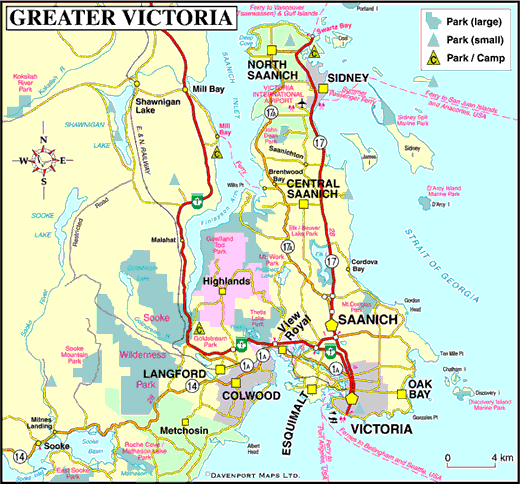

#Data ingest and EDA

We will now bring in the datasets from the weather stations and import Python libraries that we will use for our exploratory data analysis.

1. Data Collection

In [117]:
!git clone https://github.com/MantaHonk/EOS_Weather_Data_Analysis/

fatal: destination path 'EOS_Weather_Data_Analysis' already exists and is not an empty directory.


In [118]:
!pip install -q cartopy

In [119]:
#Libraries
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
import numpy as np
from scipy.stats import norm


In [120]:
folder_path = "/content/EOS_Weather_Data_Analysis"
df_a_stn_id = '1018620'
df_b_stn_id = '1018611'
#df_c_stn_id = '1018621'

#VG stands for Victoria Gonzales
df_YYJ = pd.read_parquet(f"{folder_path}/eccc_{df_a_stn_id}_daily.parquet")
df_VG = pd.read_parquet(f"{folder_path}/eccc_{df_b_stn_id}_daily.parquet")
#df_c = pd.read_parquet(f"{google_drive_folder_path}/eccc_{df_c_stn_id}_daily.parquet")

2. Data Cleaning

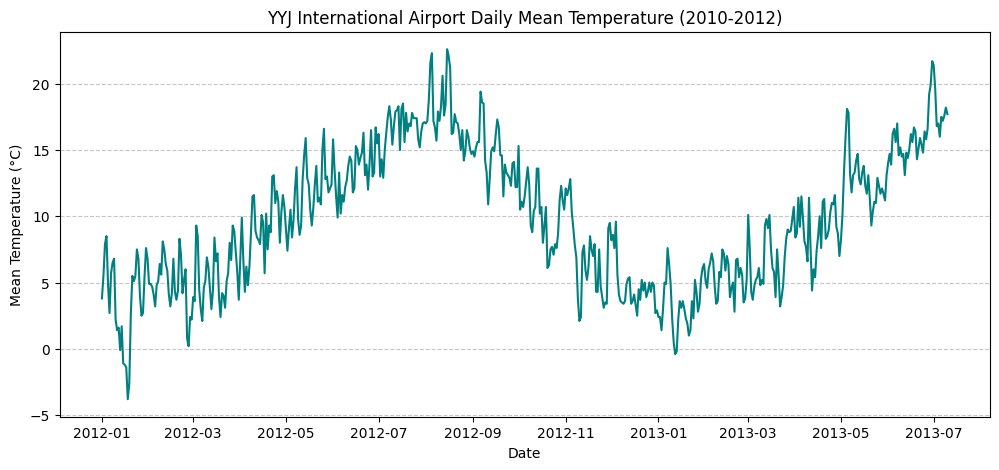

In [121]:
df_yyj_plot = df_YYJ[(df_YYJ['year'] >= 2012) & (df_YYJ['year'] <= 2013)]

plt.figure(figsize=(12, 5))
plt.plot(df_yyj_plot['timestamp'], df_yyj_plot['d_mean_temp'], color='teal')

plt.title("YYJ International Airport Daily Mean Temperature (2010-2012)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



After checking the right end point of the YYJ data, we notice that the extent of 2013 is shortened to July 10th. Since the year is not complete, we will not consider 2013 for our analysis and use 2012 as our last year of interest.

As our goal is to predict future daily mean temperatures, we must consider a reasonable period of time to measure and collect data. We will use 3 complete years to make an accurate prediction while keeping resource use low and visualizations stable. We must now check for extreme values, anomalies, and missing data within the 2010-2012 extent for both datasets.



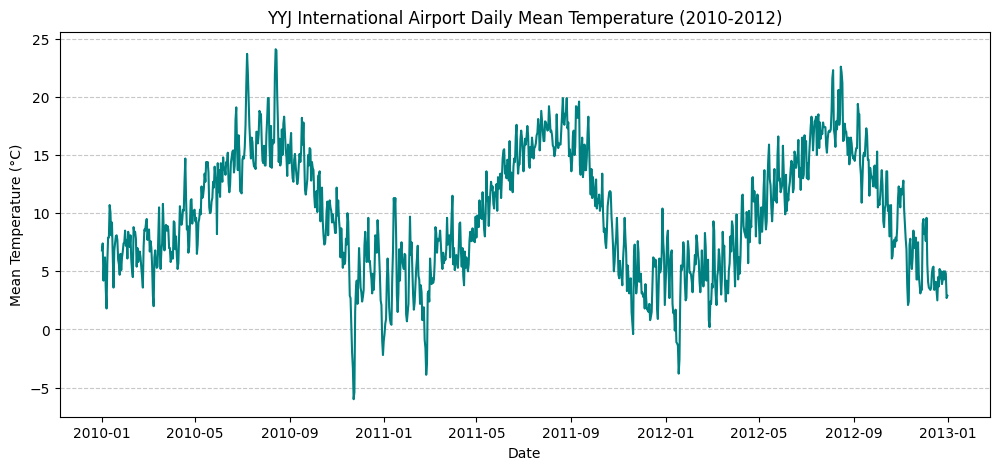

In [122]:
df_yyj_plot = df_YYJ[(df_YYJ['year'] >= 2010) & (df_YYJ['year'] <= 2012)]

plt.figure(figsize=(12, 5))
plt.plot(df_yyj_plot['timestamp'], df_yyj_plot['d_mean_temp'], color='teal')

plt.title("YYJ International Airport Daily Mean Temperature (2010-2012)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



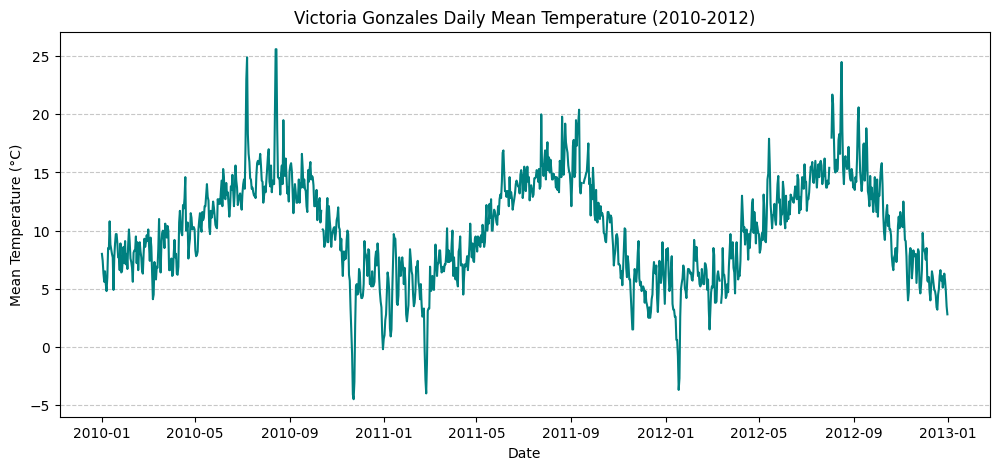

In [123]:
df_vg_plot = df_VG[(df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)]

plt.figure(figsize=(12, 5))
plt.plot(df_vg_plot['timestamp'], df_vg_plot['d_mean_temp'], color='teal')

plt.title("Victoria Gonzales Daily Mean Temperature (2010-2012)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [124]:
df_YYJ[(df_YYJ['year'] >=2010) & (df_YYJ['year'] <= 2012)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 25568 to 26663
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1096 non-null   float64       
 6   d_min_temp        1096 non-null   float64       
 7   d_mean_temp       1096 non-null   float64       
 8   total_rain        1096 non-null   float64       
 9   total_snow        1096 non-null   float64       
 10  total_precip      1096 non-null   float64       
 11  snow_on_ground    1096 non-null   float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


In [125]:
df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 13514 to 14609
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1090 non-null   float64       
 6   d_min_temp        1095 non-null   float64       
 7   d_mean_temp       1090 non-null   float64       
 8   total_rain        0 non-null      float64       
 9   total_snow        0 non-null      float64       
 10  total_precip      1081 non-null   float64       
 11  snow_on_ground    0 non-null      float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


By the .info() method, we determine that there are no missing values within the YYJ dataframe, but there are 6 missing data points for the daily mean temperature of the Victoria Gonzales dataframe.
Our procedure for fixing this is to take the mean of the first left and right non-null entries and insert the values manually.

In [126]:
df_VG_2010_2012 = df_VG[(df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)].copy()
df_VG_2010_2012['d_mean_temp'] = df_VG_2010_2012['d_mean_temp'].interpolate(method='linear', limit_direction='both')

df_VG.loc[df_VG_2010_2012.index, 'd_mean_temp'] = df_VG_2010_2012['d_mean_temp']

df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)].info()


<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 13514 to 14609
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1090 non-null   float64       
 6   d_min_temp        1095 non-null   float64       
 7   d_mean_temp       1096 non-null   float64       
 8   total_rain        0 non-null      float64       
 9   total_snow        0 non-null      float64       
 10  total_precip      1081 non-null   float64       
 11  snow_on_ground    0 non-null      float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


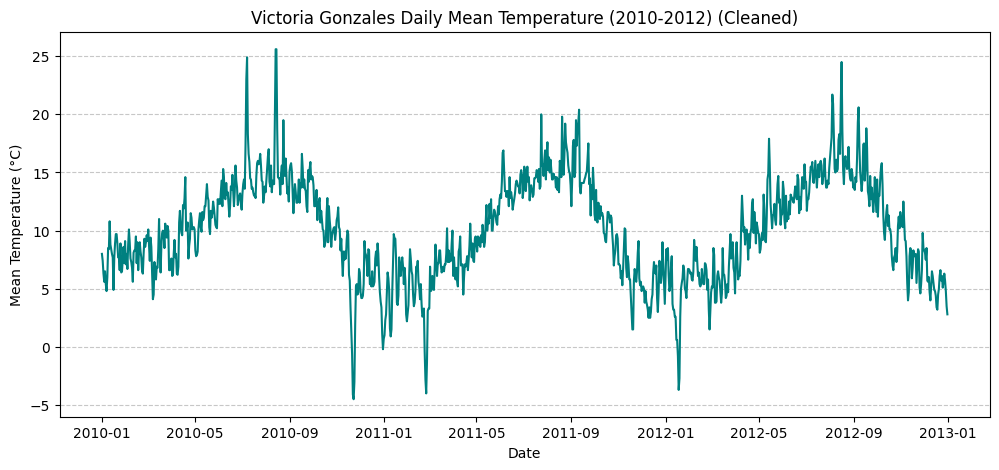

In [127]:
df_vg_plot_clean = df_VG[(df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)]

plt.figure(figsize=(12, 5))
plt.plot(df_vg_plot_clean['timestamp'], df_vg_plot_clean['d_mean_temp'], color='teal')

plt.title("Victoria Gonzales Daily Mean Temperature (2010-2012) (Cleaned)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Now that the Victoria Gonzales data no longer contains null values, we can continue our EDA.

3. Summary Statistics
We will use a side-by-side boxplot to determine how similar the two stations are, by analyzing outliers and quantiles of the stations.

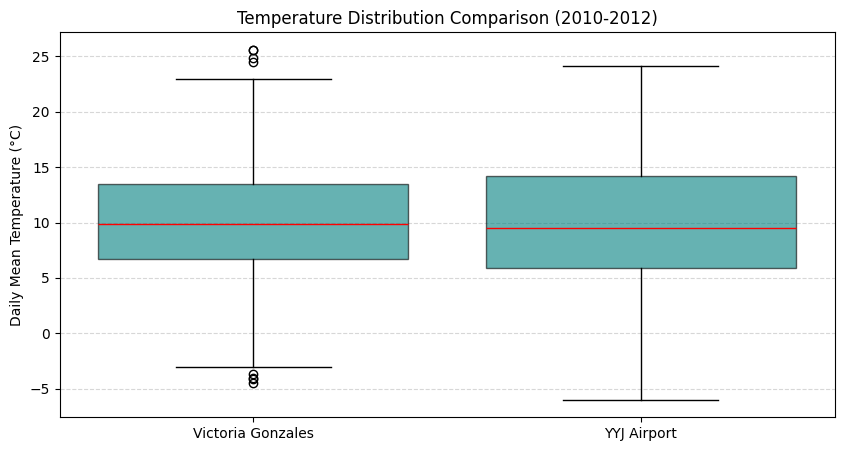

In [128]:
mask_yyj = (df_YYJ['year'] >= 2010) & (df_YYJ['year'] <= 2012)
mask_vg = (df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)
df_yyj_t = df_YYJ.loc[mask_yyj, ['timestamp', 'd_mean_temp']].rename(columns={'d_mean_temp': 'temp_yyj'})
df_vg_t = df_VG.loc[mask_vg, ['timestamp', 'd_mean_temp']].rename(columns={'d_mean_temp': 'temp_gonzales'})
df_overlap = pd.merge(df_yyj_t, df_vg_t, on='timestamp')


plt.figure(figsize=(10, 5))
plt.boxplot([df_overlap['temp_gonzales'], df_overlap['temp_yyj']],
            tick_labels=['Victoria Gonzales', 'YYJ Airport'],
            patch_artist=True, # Allows us to fill with color
            boxprops=dict(facecolor='teal', color='black', alpha=0.6),
            medianprops=dict(color='red'), widths = .8)

plt.title("Temperature Distribution Comparison (2010-2012)")
plt.ylabel("Daily Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

By looking at the boxplots, we notice that the stations are similar, but Victoria Gonzales faces more extreme temperatures and variations. We notice that the daily mean temperature is approximately 0.5 degrees cooler at YYJ, and there are no outliers during the timeframe either. However, we do notice that Victoria Gonzales has outliers on both tails. We also notice that Victoria Gonzales has a smaller IQR, meaning that there is a larger clustering of data within this range. For the most part, the boxplots follow the same spread, but Victoria Gonzales experiences more variability and has more density. Using this station to approximate YYJ International's data would show general trends, but may form some error due to these observations.

In [129]:
mu, std = norm.fit(df_overlap['delta'])

plt.figure(figsize=(10, 6))

plt.hist(df_overlap['delta'], bins=30, density=True, color='teal', edgecolor='black', alpha=0.6, label='Delta Distribution')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit (mu={mu:.2f}, sigma={std:.2f})')

plt.axvline(mu, color='red', linestyle='dashed', linewidth=2, label='Mean Delta')
plt.title("Distribution of Temperature Difference with Normal Curve Overlay", fontsize=14)
plt.xlabel("Difference (YYJ - Gonzales) (°C)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

KeyError: 'delta'

We will take the differences between the daily temperature of the two stations to determine if the errors are normal. Looking at the outputted pdf, we notice that the stations mostly fit under the normal curve. This suggests that the values are predictable, and expected. The mean is slightly shifted towards the negative side, showing that the temperature at YYJ is on average less than that of Victoria Gonzales.

4. Data Visualization

We will show the stations in proximity to towns and cities in the region. Our goal is to determine if there are any significant geographical features that could be affecting the temperatures recorded at the stations.

In [ ]:
yyj_coords = (df_YYJ['lat'].iloc[0], df_YYJ['lon'].iloc[0])
vg_coords = (df_VG['lat'].iloc[0], df_VG['lon'].iloc[0])

plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-123.75, -123.1, 48.35, 48.75], crs=ccrs.PlateCarree())

urban_areas = cfeature.NaturalEarthFeature(
    category='cultural',
    name='urban_areas',
    scale='10m',
    facecolor='teal',
    edgecolor='none'
)
ax.add_feature(urban_areas, alpha=0.5, zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.5)
ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='azure')
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f5f5f0')

roads = cfeature.NaturalEarthFeature(category='cultural', name='roads',
                                    scale='10m', facecolor='none',
                                    edgecolor='gray', linewidth=0.8)
ax.add_feature(roads, alpha=0.4)


towns = {
    "Victoria": (48.4284, -123.3656),
    "Sidney": (48.6430, -123.4000),
    "Saanich": (48.4843, -123.3814),
    "Oak Bay": (48.4264, -123.3117)
}

for town, coords in towns.items():
    ax.text(coords[1], coords[0], town, transform=ccrs.PlateCarree(),
            fontsize=10, color='dimgray', fontstyle='italic', ha='center')

ax.plot(yyj_coords[1], yyj_coords[0], 'ro', markersize=10, transform=ccrs.PlateCarree(), label="YYJ Airport")
ax.text(yyj_coords[1]+0.01, yyj_coords[0], "YYJ Airport", transform=ccrs.PlateCarree(), fontweight='bold')

ax.plot(vg_coords[1], vg_coords[0], 'ro', markersize=10, transform=ccrs.PlateCarree(), label="Gonzales Stn")
ax.text(vg_coords[1]+0.01, vg_coords[0], "Victoria Gonzales", transform=ccrs.PlateCarree(), fontweight='bold')

plt.title("South Vancouver Island: Station Proximity to Urban Centers", fontsize=15)
plt.show()

From the cartographic visualization, we notice the proximity of the two stations, with the distance between the two being roughly 25 kms. We notice that both locations are close to the ocean, but Victoria Gonzales is more direct, whereas the airport is more inland.

Note: for more detail of the Capital Region District, see Figure 1 above.

6. Correlation Analysis

We want to ensure that Victoria Gonzales will be an adequate station to use as a reference for our additional data we want to estimate. We will use a scatterplot and plot daily mean temperatures for both of the data sets. From this, we will find the R^2 value and determine if there is any correlation between the two stations.

In [ ]:
z = np.polyfit(df_overlap['temp_gonzales'], df_overlap['temp_yyj'], 1)
p = np.poly1d(z)


plt.figure(figsize=(10, 6))


plt.scatter(df_overlap['temp_gonzales'], df_overlap['temp_yyj'],
            alpha=0.4, s=15, color='teal', label='Daily Observations')


x_range = np.linspace(df_overlap['temp_gonzales'].min(), df_overlap['temp_gonzales'].max(), 100)
plt.plot(x_range, p(x_range), color='red', linewidth=2, label=f'Trendline (Slope: {z[0]:.4f})')


plt.title("Temperature Correlation: Gonzales vs. YYJ (2010-2012)", fontsize=14)
plt.xlabel("Victoria Gonzales Mean Temp (°C)", fontsize=12)
plt.ylabel("YYJ Airport Mean Temp (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.text(-3, 22, f'$R^2 = 0.9410$', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

From the plot, we see that there is a high correlation, suggesting a strong fit. We will now test to see if there is any additional information we are missing, particularily in seasonal changes. We will break the scatterplot into summer and winter and test their individual correlations.



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, season in zip([ax1, ax2], ['Summer', 'Winter']):

    data = df_overlap[df_overlap['season'] == season]


    ax.scatter(data['temp_gonzales'], data['temp_yyj'], alpha=0.4, color='teal', s=15, label='Actual Data')

    slope, intercept = np.polyfit(data['temp_gonzales'], data['temp_yyj'], 1)
    line_fn = np.poly1d([slope, intercept])

    x_range = np.linspace(data['temp_gonzales'].min(), data['temp_gonzales'].max(), 100)
    ax.plot(x_range, line_fn(x_range), color='red', linewidth=2, label=f'Trend (Slope: {slope:.2f})')

    corr = data['temp_gonzales'].corr(data['temp_yyj'])

    ax.set_title(f"{season} Relationship (R = {corr:.3f})")
    ax.set_xlabel("Victoria Gonzales Mean Temp (°C)")
    if ax == ax1: ax.set_ylabel("YYJ Temp (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Seasonal Microclimate Correlation Analysis", fontsize=16)
plt.show()

We notice that there was in fact some seasonal trends we missed during our first correlation analysis. The winter relationship is stronger than the summer, with a larger spread of data along the trendline. The summer data appears to have a stronger clustering, but more outliers especially on the warmer end of the scale. This shows that Victoria Gonzales is more prone to extreme warm temperatures than YYJ Airport.



In [ ]:
df_overlap['predicted_yyj'] = z[0] * df_overlap['temp_gonzales'] + z[1]
df_overlap['residuals'] = df_overlap['temp_yyj'] - df_overlap['predicted_yyj']

plt.figure(figsize=(12, 5))
plt.scatter(df_overlap['timestamp'], df_overlap['residuals'], color='purple', alpha=0.5, s=10)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Residual Analysis: Prediction Error Over Time (2010-2012)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted) (°C)")
plt.grid(True, alpha=0.3)
plt.show()